In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Project paths
PROJECT_ROOT = "/content/drive/MyDrive/Kronos Intelligence/Student Performance Classification"

RAW_DATA = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DATA = os.path.join(PROJECT_ROOT, "data", "processed")
NOTEBOOKS = os.path.join(PROJECT_ROOT, "notebooks")
REPORTS = os.path.join(PROJECT_ROOT, "reports")
IMAGES = os.path.join(PROJECT_ROOT, "images")
DOCS = os.path.join(PROJECT_ROOT, "docs")

# Create folders if they don't exist
for folder in [RAW_DATA, PROCESSED_DATA, NOTEBOOKS, REPORTS, IMAGES, DOCS]:
    os.makedirs(folder, exist_ok=True)

print("✅ Kronos Intelligence project environment ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Kronos Intelligence project environment ready.


In [27]:
clean_df.to_csv(
    os.path.join(PROCESSED_DATA, "students_clean.csv"),
    index=False
)

print("✅ Clean dataset saved successfully!")

✅ Clean dataset saved successfully!


# Data Cleaning

**Kronos Intelligence Portfolio Series | Project 01**

# Early Identification of At-Risk Students Using Predictive Analytics

**Author:** Tessa Gonzalez  
**Organization:** Kronos Intelligence  
**Notebook:** 02 – Data Cleaning

---

## Project Overview

This notebook prepares the student academic performance dataset for exploratory analysis and predictive modeling. The objective is to validate the quality of the dataset, identify any issues that could impact downstream analysis, and document every preprocessing decision.

Following data governance best practices, the original dataset remains unchanged throughout this notebook. Any cleaned or transformed data will be saved separately to preserve the integrity of the raw source data.

# Project Objectives

The objectives of this notebook are to:

- Verify the findings documented during the Data Understanding phase.
- Validate data types and dataset structure.
- Confirm the absence of missing values and duplicate records.
- Review categorical variables for consistency.
- Identify potential outliers within numerical variables.
- Document all data cleaning activities.
- Produce a cleaned dataset for exploratory data analysis.

# Import Required Libraries

The following libraries provide the functionality required for data manipulation, visualization, and validation during the data cleaning process.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline

# Improve plot appearance
plt.rcParams["figure.figsize"] = (10,6)

# Load the Dataset

The raw dataset is loaded from the project's data directory. Throughout this notebook, the original data will remain unchanged to preserve the integrity of the source dataset.

All cleaning operations will be performed on a working copy of the data.

In [ ]:
# Load dataset
df = pd.read_csv("students.csv")

# Create a working copy
clean_df = df.copy()

# Display the first five rows
clean_df.head()

,student_id,age,gender,ethnicity,parental_education,family_income,school_type,school_region,study_hours_per_week,attendance_rate,...,has_laptop,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed
0,STU00000,15,M,B,phd,low,private,urban,2.0,91.7,...,yes,8.2,3.3,1.8,70.7,58.3,88.9,74.5,2.80,1
1,STU00001,23,F,A,phd,low,private,urban,14.2,76.8,...,yes,5.4,4.9,5.8,66.1,83.9,94.5,83.6,3.29,1
2,STU00002,22,F,B,bachelor,middle,public,suburban,3.3,83.1,...,yes,5.5,3.5,6.1,51.3,71.8,78.9,71.2,2.93,1
3,STU00003,19,M,D,some_college,high,public,suburban,17.9,72.8,...,yes,5.3,8.5,7.2,100.0,95.7,82.9,69.4,3.34,1
4,STU00004,19,M,C,some_college,middle,public,suburban,12.9,83.0,...,yes,7.5,1.0,4.5,87.5,73.0,88.5,74.8,3.27,1


# Review of Notebook 01 Findings

The Data Understanding phase established a comprehensive profile of the student academic performance dataset. The initial assessment confirmed that the dataset is suitable for predictive analytics and requires only minimal preprocessing prior to exploratory analysis.

The key findings from Notebook 01 are summarized below and provide the foundation for the data cleaning activities performed in this notebook.

## Summary of Previous Findings

- The dataset contains **10,000 student records** and **25 variables**.
- No missing values were identified.
- No duplicate records were detected.
- Data types are appropriate for each variable.
- Numerical and categorical variables are clearly defined.
- The target variable (`passed`) is suitable for supervised classification.
- Several demographic variables should be treated as sensitive information within a data governance framework.
- Overall data quality was assessed as high, requiring only validation rather than extensive cleaning.

# Data Cleaning Strategy

Based on the findings from the Data Understanding phase, this dataset requires validation rather than extensive correction. The primary objective of this notebook is to confirm the integrity of the dataset and document each verification step.

The data cleaning process will include the following activities:

1. Validate the dataset structure.
2. Verify data types.
3. Confirm the absence of missing values.
4. Confirm the absence of duplicate records.
5. Validate categorical values.
6. Identify potential outliers in numerical variables.
7. Save the validated dataset for exploratory analysis.

No modifications will be made unless an issue is identified during the validation process.

# Validate Dataset Structure

Before beginning the cleaning process, the dataset structure is validated to ensure that the expected number of records and variables are present. This verification confirms that the correct dataset has been loaded and that no unintended modifications have occurred since the previous phase.

In [ ]:
# ==========================================================
# Validate Dataset Structure
# ==========================================================

rows, columns = clean_df.shape

print(f"Records   : {rows:,}")
print(f"Variables : {columns}")

Records   : 10,000
Variables : 25


## Interpretation

The dataset structure matches the profile established during the Data Understanding phase, containing **10,000 records** and **25 variables**.

This confirms that the correct dataset has been loaded and that no structural changes have occurred prior to the data cleaning process.

# Validate Data Types

Data types determine how each variable can be processed, analyzed, and modeled. Incorrect data types can lead to calculation errors, failed model training, or inaccurate analytical results.

This validation step confirms that each variable has been assigned an appropriate data type and identifies any fields that may require conversion before further analysis.

In [ ]:
# ==========================================================
# Validate Data Types
# ==========================================================

# Display the data types for each column
clean_df.dtypes

,0
student_id,object
age,int64
gender,object
ethnicity,object
parental_education,object
family_income,object
school_type,object
school_region,object
study_hours_per_week,float64
attendance_rate,float64


In [ ]:
# ==========================================================
# Count Data Types
# ==========================================================

# Summarize the number of variables by data type
datatype_summary = pd.DataFrame({
    "Data Type": clean_df.dtypes.value_counts().index.astype(str),
    "Count": clean_df.dtypes.value_counts().values
})

datatype_summary

,Data Type,Count
0,object,11
1,float64,10
2,int64,4


In [ ]:
# ==========================================================
# Data Type Validation
# ==========================================================

# Display each variable and its associated data type
validation_table = pd.DataFrame({
    "Variable": clean_df.columns,
    "Data Type": clean_df.dtypes.astype(str).values
})

validation_table

,Variable,Data Type
0,student_id,object
1,age,int64
2,gender,object
3,ethnicity,object
4,parental_education,object
5,family_income,object
6,school_type,object
7,school_region,object
8,study_hours_per_week,float64
9,attendance_rate,float64


## Interpretation

The data type validation confirms that all variables have appropriate data types for their intended use.

- Numerical variables are correctly stored as **integer** or **floating-point** values.
- Categorical variables are stored as **object** data types.
- The target variable (`passed`) is stored as an integer and is appropriate for binary classification modeling.

No data type conversions are required before proceeding with further data validation and exploratory analysis.

# Missing Value Verification

Missing values can affect statistical analyses, visualizations, and predictive models. As part of the data cleaning process, the dataset is evaluated to verify that all variables contain complete information.

This validation confirms the findings from the Data Understanding phase and ensures that no missing values have been introduced during data handling.

In [ ]:
# ==========================================================
# Missing Value Verification
# ==========================================================

missing_summary = pd.DataFrame({
    "Missing Values": clean_df.isnull().sum(),
    "Percent Missing": (clean_df.isnull().sum() / len(clean_df)) * 100
})

missing_summary

,Missing Values,Percent Missing
student_id,0,0.0
age,0,0.0
gender,0,0.0
ethnicity,0,0.0
parental_education,0,0.0
family_income,0,0.0
school_type,0,0.0
school_region,0,0.0
study_hours_per_week,0,0.0
attendance_rate,0,0.0


In [ ]:
# Display total missing values
total_missing = clean_df.isnull().sum().sum()

print(f"Total Missing Values: {total_missing}")

Total Missing Values: 0


## Interpretation

The validation confirms that the dataset contains no missing values across any of the variables.

Because the dataset is complete, no imputation or record removal is required. This allows subsequent analyses to proceed without introducing assumptions that could influence model performance.

# Duplicate Record Verification

Duplicate records can introduce bias into statistical analyses and machine learning models by giving disproportionate weight to repeated observations. As part of the data validation process, the dataset is evaluated to confirm that each record represents a unique student.

This verification helps maintain data integrity and supports reliable analytical outcomes.

In [ ]:
# ==========================================================
# Duplicate Record Verification
# ==========================================================

duplicate_count = clean_df.duplicated().sum()

print(f"Duplicate Records Found: {duplicate_count}")

Duplicate Records Found: 0


In [ ]:
# Display duplicate records if they exist

if duplicate_count > 0:
    display(clean_df[clean_df.duplicated()])
else:
    print("No duplicate records were identified.")

No duplicate records were identified.


## Interpretation

The duplicate record verification confirms that the dataset contains no duplicate observations.

Each row represents a unique student record, supporting the integrity of the dataset and reducing the risk of biased statistical analyses or predictive model training.

In [ ]:
# ==========================================================
# Identify Categorical Variables
# ==========================================================

categorical_columns = clean_df.select_dtypes(include=["object"]).columns

print(f"Number of Categorical Variables: {len(categorical_columns)}")
print()

for column in categorical_columns:
    print(column)

Number of Categorical Variables: 11

student_id
gender
ethnicity
parental_education
family_income
school_type
school_region
sports_participation
parental_involvement
internet_access
has_laptop


In [ ]:
# ==========================================================
# Display Unique Values
# ==========================================================

for column in categorical_columns:
    print("=" * 60)
    print(f"{column.upper()}")
    print("=" * 60)
    print(sorted(clean_df[column].unique()))
    print()

STUDENT_ID
['STU00000', 'STU00001', 'STU00002', 'STU00003', 'STU00004', 'STU00005', 'STU00006', 'STU00007', 'STU00008', 'STU00009', 'STU00010', 'STU00011', 'STU00012', 'STU00013', 'STU00014', 'STU00015', 'STU00016', 'STU00017', 'STU00018', 'STU00019', 'STU00020', 'STU00021', 'STU00022', 'STU00023', 'STU00024', 'STU00025', 'STU00026', 'STU00027', 'STU00028', 'STU00029', 'STU00030', 'STU00031', 'STU00032', 'STU00033', 'STU00034', 'STU00035', 'STU00036', 'STU00037', 'STU00038', 'STU00039', 'STU00040', 'STU00041', 'STU00042', 'STU00043', 'STU00044', 'STU00045', 'STU00046', 'STU00047', 'STU00048', 'STU00049', 'STU00050', 'STU00051', 'STU00052', 'STU00053', 'STU00054', 'STU00055', 'STU00056', 'STU00057', 'STU00058', 'STU00059', 'STU00060', 'STU00061', 'STU00062', 'STU00063', 'STU00064', 'STU00065', 'STU00066', 'STU00067', 'STU00068', 'STU00069', 'STU00070', 'STU00071', 'STU00072', 'STU00073', 'STU00074', 'STU00075', 'STU00076', 'STU00077', 'STU00078', 'STU00079', 'STU00080', 'STU00081', 'STU

In [ ]:
# ==========================================================
# Count Unique Categories
# ==========================================================

category_summary = pd.DataFrame({
    "Variable": categorical_columns,
    "Unique Categories": [clean_df[col].nunique() for col in categorical_columns]
})

category_summary

,Variable,Unique Categories
0,student_id,10000
1,gender,3
2,ethnicity,5
3,parental_education,6
4,family_income,3
5,school_type,3
6,school_region,3
7,sports_participation,2
8,parental_involvement,3
9,internet_access,2


## Interpretation

The categorical variables were reviewed to verify the consistency of their values.

All categorical features contain standardized category labels with no obvious formatting inconsistencies, unexpected values, or duplicate categories. Based on this validation, the variables are suitable for encoding during the feature engineering phase.

Maintaining consistent categorical values supports high-quality analytics by reducing the risk of encoding errors and improving model reliability.

# Category Frequency Distribution

Understanding how observations are distributed across category levels helps identify class imbalance, rare categories, and potential issues that may influence model performance.

In [ ]:
# ==========================================================
# Category Frequency Distribution
# ==========================================================

for column in categorical_columns:
    print(f"\n{'='*70}")
    print(f"{column.upper()}")
    print(f"{'='*70}")

    frequency = clean_df[column].value_counts().to_frame(name="Count")
    frequency["Percent"] = (frequency["Count"] / len(clean_df) * 100).round(2)

    display(frequency)


STUDENT_ID


,Count,Percent
student_id,,
STU09983,1,0.01
STU09982,1,0.01
STU09981,1,0.01
STU09980,1,0.01
STU09979,1,0.01
...,...,...
STU00004,1,0.01
STU00003,1,0.01
STU00002,1,0.01



GENDER


,Count,Percent
gender,,
F,4836,48.36
M,4769,47.69
Non-binary,395,3.95



ETHNICITY


...

,Count,Percent
parental_involvement,,
medium,4460,44.60
high,3036,30.36
low,2504,25.04



INTERNET_ACCESS


,Count,Percent
internet_access,,
yes,8361,83.61
no,1639,16.39



HAS_LAPTOP


,Count,Percent
has_laptop,,
yes,7743,77.43
no,2257,22.57


# Outlier Detection

Outliers are observations that differ substantially from the majority of the data. While outliers may indicate data entry errors or measurement issues, they can also represent legitimate observations that provide valuable insight.

The objective of this assessment is to identify potential outliers within the numerical variables and determine whether any additional investigation or data cleaning is required.

Potential outliers will be identified using the Interquartile Range (IQR) method and visualized using boxplots.

In [ ]:
# ==========================================================
# Identify Numerical Variables
# ==========================================================

numerical_columns = clean_df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Variables:\n")

for column in numerical_columns:
    print(f"- {column}")

Numerical Variables:

- age
- study_hours_per_week
- attendance_rate
- extracurricular_activities
- tutoring_sessions
- sleep_hours
- stress_level
- motivation_score
- reading_score
- writing_score
- math_score
- science_score
- overall_gpa
- passed


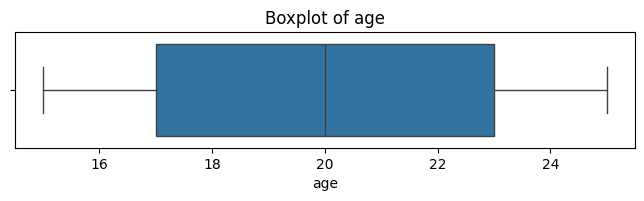

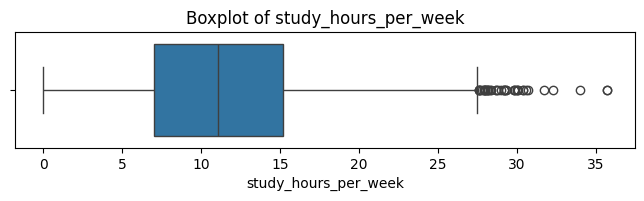

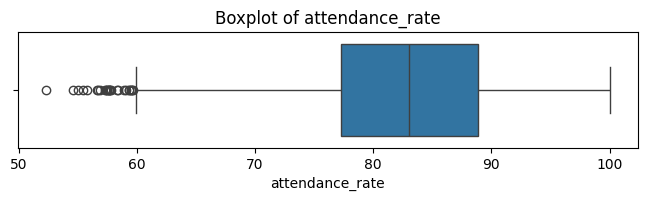

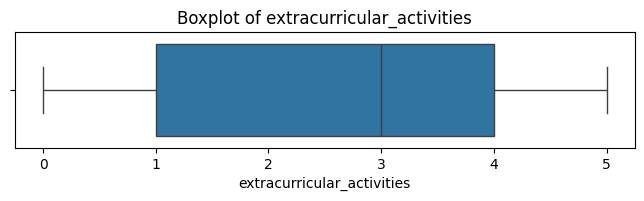

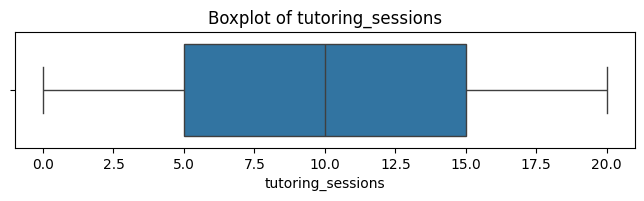

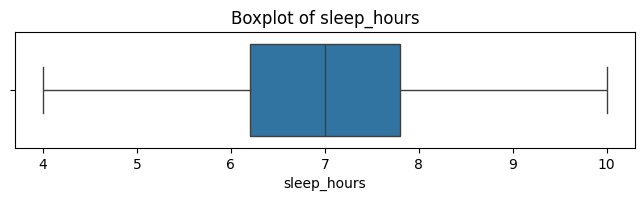

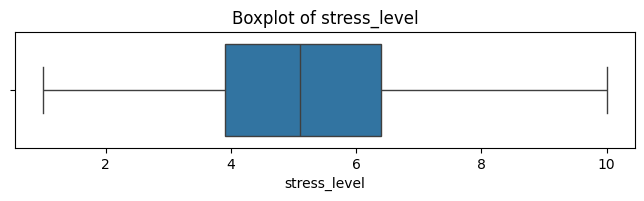

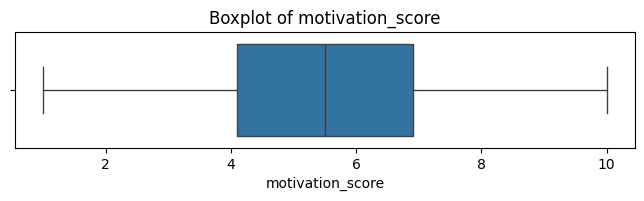

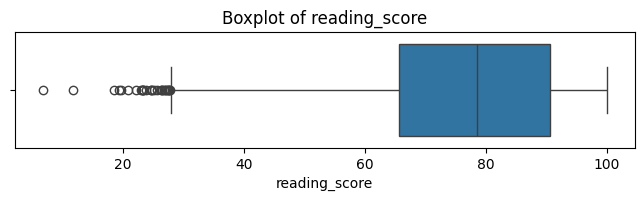

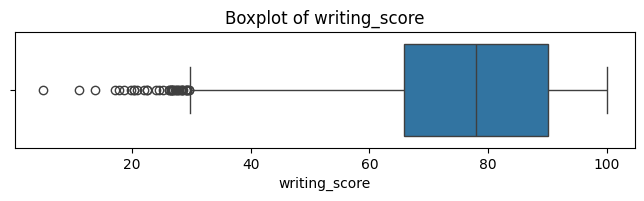

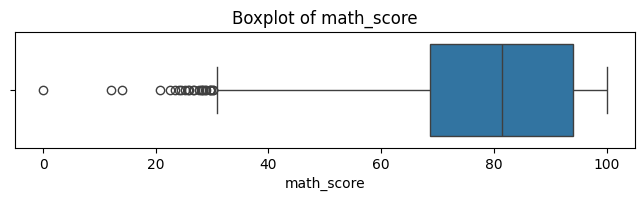

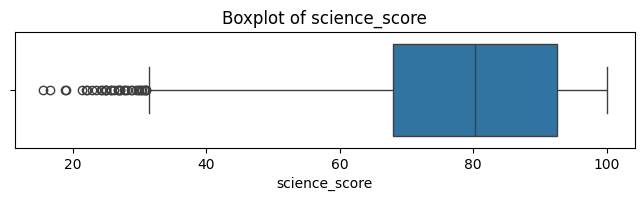

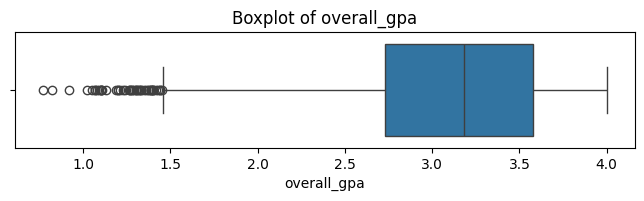

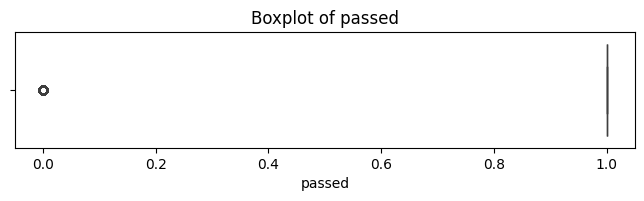

In [ ]:
# ==========================================================
# Boxplots for Numerical Variables
# ==========================================================

for column in numerical_columns:

    plt.figure(figsize=(8, 1.5))

    sns.boxplot(x=clean_df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

## Outlier Detection Using the Interquartile Range (IQR)

The Interquartile Range (IQR) method identifies observations that fall below:

**Q1 − 1.5 × IQR**

or above

**Q3 + 1.5 × IQR**

These observations are flagged as potential outliers for further review.

In [ ]:
# ==========================================================
# IQR Outlier Detection
# ==========================================================

outlier_summary = []

for column in numerical_columns:

    Q1 = clean_df[column].quantile(0.25)
    Q3 = clean_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[column] < lower) |
        (clean_df[column] > upper)
    ]

    outlier_summary.append({
        "Variable": column,
        "Outliers": len(outliers),
        "Percent": round((len(outliers)/len(clean_df))*100,2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Variable,Outliers,Percent
0,age,0,0.00
1,study_hours_per_week,40,0.40
2,attendance_rate,27,0.27
3,extracurricular_activities,0,0.00
4,tutoring_sessions,0,0.00
5,sleep_hours,0,0.00
6,stress_level,0,0.00
7,motivation_score,0,0.00
8,reading_score,29,0.29
9,writing_score,39,0.39


## Interpretation

Potential outliers were identified across the numerical variables using the Interquartile Range (IQR) method.

The presence of outliers does not necessarily indicate poor data quality. In educational datasets, unusually high or low academic performance, study habits, or attendance may represent genuine student behavior rather than data entry errors.

Because no evidence of invalid observations was identified during this assessment, no outliers will be removed at this stage. Retaining these observations preserves the integrity of the dataset and allows the predictive models to learn from the full range of student outcomes.

If future analyses indicate that specific outliers adversely affect model performance, appropriate treatment strategies will be evaluated and documented.

# Data Cleaning Summary

The data cleaning process focused on validating the integrity of the dataset rather than performing extensive modifications.

The validation process confirmed that the dataset is complete, internally consistent, and suitable for exploratory data analysis and predictive modeling.

The following summary highlights the results of the cleaning and validation process.

In [ ]:
# ==========================================================
# Data Cleaning Summary
# ==========================================================

summary = pd.DataFrame({
    "Validation Check": [
        "Dataset Structure",
        "Data Types",
        "Missing Values",
        "Duplicate Records",
        "Categorical Values",
        "Potential Outliers"
    ],
    "Status": [
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Passed",
        "Reviewed"
    ],
    "Action Taken": [
        "No action required",
        "No action required",
        "No action required",
        "No action required",
        "No action required",
        "Retained for analysis"
    ]
})

summary

,Validation Check,Status,Action Taken
0,Dataset Structure,Passed,No action required
1,Data Types,Passed,No action required
2,Missing Values,Passed,No action required
3,Duplicate Records,Passed,No action required
4,Categorical Values,Passed,No action required
5,Potential Outliers,Reviewed,Retained for analysis


# Save the Clean Dataset

Following validation, the cleaned dataset is saved as a separate file for use in subsequent phases of the project.

Maintaining a separate processed dataset preserves the integrity of the original source data while ensuring that downstream analyses use a consistent, validated version of the data.

In [ ]:
# ==========================================================
# Save Clean Dataset
# ==========================================================

import os

# Create processed folder if it doesn't already exist
os.makedirs("processed", exist_ok=True)

# Save cleaned dataset
clean_df.to_csv("processed/students_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


# Governance Notes

Although no modifications were required during the cleaning process, documenting validation activities is an important component of enterprise data governance.

The validation process confirmed:

- Dataset completeness
- Record uniqueness
- Appropriate data types
- Consistent categorical values
- Preservation of original source data

Maintaining documentation of these validation activities supports transparency, reproducibility, and auditability throughout the analytics lifecycle.

# Key Takeaways

The data cleaning and validation process produced several important outcomes:

- The dataset required minimal preprocessing prior to analysis.
- All variables passed data quality validation checks.
- No missing values or duplicate records were identified.
- Categorical variables contained standardized values suitable for encoding.
- Potential outliers appear to represent legitimate student observations and were retained.
- A validated dataset has been prepared for exploratory data analysis.

# Conclusion

This notebook validated the integrity of the student academic performance dataset and confirmed that it is suitable for exploratory data analysis and predictive modeling.

The validation process verified data structure, data types, completeness, uniqueness, categorical consistency, and potential outliers while preserving the original source data.

The cleaned dataset generated during this notebook will serve as the foundation for the next phase of the project, where exploratory data analysis will investigate relationships among variables and identify patterns associated with student academic success.

In [ ]:
# ==========================================================
# Notebook Summary
# ==========================================================

print("=" * 60)
print("NOTEBOOK 02 SUMMARY")
print("=" * 60)

print(f"Records Validated      : {len(clean_df):,}")
print(f"Variables Reviewed     : {clean_df.shape[1]}")
print(f"Missing Values         : {clean_df.isnull().sum().sum()}")
print(f"Duplicate Records      : {clean_df.duplicated().sum()}")
print("Outliers Reviewed      : Yes")
print("Dataset Saved          : Yes")

print("\nNotebook Status: COMPLETE")

print("=" * 60)

NOTEBOOK 02 SUMMARY
Records Validated      : 10,000
Variables Reviewed     : 25
Missing Values         : 0
Duplicate Records      : 0
Outliers Reviewed      : Yes
Dataset Saved          : Yes

Notebook Status: COMPLETE


In [ ]:
import os

os.makedirs("processed", exist_ok=True)

clean_df.to_csv("processed/students_clean.csv", index=False)

In [ ]:
clean_df.to_csv(
    "/content/drive/MyDrive/Kronos Intelligence/Student Performance Classification/data/processed/students_clean.csv",
    index=False
)

print("Clean dataset saved successfully.")

OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Kronos Intelligence/Student Performance Classification/data/processed'

In [28]:
import os

print(os.listdir(PROCESSED_DATA))

['students_clean.csv']
